In [1]:
import os
import numpy as np
import cv2
import torch
from typing import List, Callable, Optional
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from PIL import Image, ImageDraw
from pathlib import Path

In [2]:
# Set environment variable to avoid symbolic tracing issues
os.environ['TIMM_FUSED_ATTN'] = '0'
from torchvision import transforms
from pytorch_grad_cam import run_dff_on_image, GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Import XAI methods
from baselines.GradCAM_v2 import PytorchCAM
from baselines.RISE import RISEBatch
from baselines.Attention import Attention_Map
from baselines.TransformerAttribution import TransformerAttribution as TFAttribution
#from baselines.CRP_LXT import CRP_LXT
from pytorch_grad_cam import GradCAM as GradCAMv2, ScoreCAM, HiResCAM, GradCAMPlusPlus

In [3]:
from transformers import (
    ViTImageProcessor, ViTForImageClassification,
    AutoImageProcessor, EfficientNetForImageClassification,
    ResNetForImageClassification, AutoModel
)
import models_vit as models
from util.datasets import TransformWrapper
import timm
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

#transform
def eval_transform(input_size):
    mean = IMAGENET_DEFAULT_MEAN
    std = IMAGENET_DEFAULT_STD
    t = []
    if input_size <= 224:
        crop_pct = 224 / 256
    else:
        crop_pct = 1.0
    size = int(input_size / crop_pct)
    t.append(
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BICUBIC),
    )
    t.append(transforms.CenterCrop(input_size))
    t.append(transforms.ToTensor())
    t.append(transforms.Normalize(mean, std))
    return transforms.Compose(t)

#get model
def get_model(task,model,input_size,nb_classes):
    if 'ADCon' in task:
        id2label = {0: "control", 1: "ad"}
        label2id = {v: k for k, v in id2label.items()}
    else:
        id2label = {i: f"class_{i}" for i in range(nb_classes)}
        label2id = {v: k for k, v in id2label.items()}
    processor = None
    if 'RETFound_mae' in model:
        model = models.__dict__['RETFound_mae'](
        img_size=input_size,
        num_classes=nb_classes,
        drop_path_rate=0.2,
        global_pool=True,
    )
    elif 'vit-base-patch16-224' in model:
        # ViT-base-patch16-224 preprocessor
        model_ = 'google/vit-base-patch16-224'
        processor = TransformWrapper(ViTImageProcessor.from_pretrained(model_))
        model = ViTForImageClassification.from_pretrained(
            model_,
            image_size=input_size, #Not in tianhao code, default 224
            num_labels=nb_classes,
            hidden_dropout_prob=0.0, #Not in tianhao code, default 0.0
            attention_probs_dropout_prob=0.0, #Not in tianhao code, default 0.0
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True,
            attn_implementation="eager",      # ← key line
        )
        model.config.return_dict = True
        model.config.output_attentions = True
    elif 'timm_efficientnet-b4' in model:
        model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=nb_classes)
        processor  = transforms.Compose([
            transforms.Resize((380,380)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    elif 'ResNet-50' in model:
        model_name = 'microsoft/resnet-50'
        processor = TransformWrapper(AutoImageProcessor.from_pretrained(model_name))
        model = ResNetForImageClassification.from_pretrained(
            model_name,
            num_labels=nb_classes,
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True
        )
        model.config.return_dict = True
        model.config.output_attentions = True
    elif 'SMP' in model:
        from SMP.smp_classifier import SMPClassifier, Config as SMPConfig
        if 'dec' in model:
            mode = 'dec'
        else:
            mode = 'enc'
        model = SMPClassifier(
            seg_arch=SMPConfig.SEG_ARCH,
            encoder_name=SMPConfig.ENCODER,
            encoder_weights=SMPConfig.ENCODER_WEIGHTS,
            in_channels=SMPConfig.IN_CHANNELS,
            num_classes=nb_classes,
            mode=mode,
            fuse_mode=SMPConfig.FUSE_MODE,
            learnable_alpha=SMPConfig.LEARNABLE_ALPHA,
            alpha=SMPConfig.ALPHA,
            pretrained_seg_ckpt="/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth",
            dropout=SMPConfig.DROPOUT,
        )

    return model, processor

# Data Load

In [14]:
# task and dataset
#Task_list = ['ADCon','DME']
LOAD_MASK = True
IMG_MASK = True
HEATMAP_MASK = False
DRAW_LAYER = True
N_CASES = 10          # number of per-image case study visualizations to produce
N_TEST_SAMPLES = 200  # how many test samples to evaluate over
Thickness_DIR = "/orange/ruogu.fang/tienyuchang/IRB2024_OCT_thickness/Data/"
Thickness_CSV = "/orange/ruogu.fang/tienyuchang/IRB2024_OCT_thickness/thickness_map.csv"
Task_list = ['DME']
dataset_fname = 'sampled_labels01.csv'
dataset_dir = '/blue/ruogu.fang/tienyuchang/OCT_EDA'
img_p_fmt = "label_%d/%s" #label index and oct_img name

# model
Model_root = "/blue/ruogu.fang/tienyuchang/RETFound_MAE/output_dir"
Model_fname = "checkpoint-best.pth"
Model_list = ['RETFound_mae']
Model_image_size_list = [224]

ADCon_finetuned = [
    "ad_control_detect_data-IRB2024v5_ADCON_DL_data-all-resnet-50-OCT-defaulteval---bal_sampler-/",
    "ad_control_detect_data-IRB2024v5_ADCON_DL_data-all-timm_efficientnet-b4-OCT-defaulteval---bal_sampler-/",
    "ad_control_detect_data-IRB2024v5_ADCON_DL_data-all-vit-base-patch16-224-OCT-defaulteval---bal_sampler-/",
    "ad_control_detect_data-IRB2024v5_ADCON_DL_data-all-RETFound_mae-OCT-defaulteval---bal_sampler-/",
    "","","",""
]
DME_finetuned = [
    "DME_binary_all_split-IRB2024_v5-all-microsoft/resnet-50-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0--/",
    "DME_binary_all_split-IRB2024_v5-all-timm_efficientnet-b4-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0--/",
    "DME_binary_all_split-IRB2024_v5-all-google/vit-base-patch16-224-in21k-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0--/",
    "DME_binary_all_split-IRB2024_v5-all-RETFound_mae_natureOCT-OCT-bs16ep50lr5e-4optadamw-roc_auceval-trsub0--/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0-enc--/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0--/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs8ep50lr5e-4optadamw-defaulteval-trsub0-enc---fix_extractor--/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0-dec---fix_extractor--/"
]

Model_root = "/orange/ruogu.fang/tienyuchang/RETfound_results"
DME_finetuned_masked = [
    "DME_binary_all_split-IRB2024_v5-all-microsoft/resnet-50-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-timm_efficientnet-b4-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-google/vit-base-patch16-224-in21k-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-RETFound_mae_natureOCT-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0-enc---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs8ep50lr1e-2optadamw-defaulteval-trsub0-enc---add_mask---train_no_aug---fix_extractor/",
    "DME_binary_all_split-IRB2024_v5-all-/blue/ruogu.fang/tienyuchang/RETFound_MAE/Seg_checkpoints/best_model_multiclass.pth-OCT-bs4ep20lr1e-4optadamw-defaulteval-trsub0-dec---add_mask---train_no_aug---fix_extractor/"
]


After adding mask, data len:  198
198
<PIL.Image.Image image mode=RGB size=512x496 at 0x148297306130>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


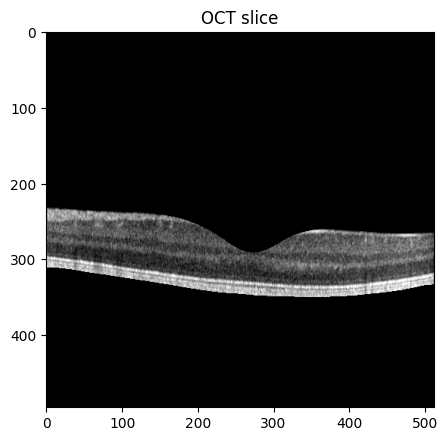

[[233 233 233 ... 266 266 265]
 [248 248 248 ... 268 268 268]
 [254 254 254 ... 274 274 274]
 ...
 [302 302 302 ... 325 325 324]
 [306 306 306 ... 329 329 329]
 [312 312 312 ... 334 334 334]]
(496, 512, 3)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


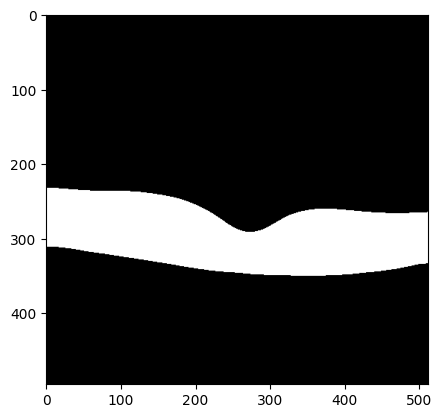

In [5]:
def _build_binary_mask(mask_slice, heatmap):
    binary_mask = np.zeros((heatmap.shape[0],heatmap.shape[1]), dtype=np.uint8)
    for i in range(mask_slice.shape[0]-1):
        upper = mask_slice[i].astype(int)
        lower = mask_slice[i+1].astype(int)
        for x in range(heatmap.shape[1]):
            binary_mask[upper[x]:lower[x], x] = 1
    return binary_mask
#mask function
def masked_img_func(img, mask_slice):
    binary_mask = _build_binary_mask(mask_slice, img)

    # 套用 mask (把 mask=0 的地方設為 0)
    masked_img = img.copy()
    masked_img[binary_mask == 0] = 0

    return masked_img

# Data loading and preprocessing functions
def load_sample_data(task, num_sample=-1, save_mask=False):
    """Load sample images for a given task"""
    df = pd.read_csv(os.path.join(dataset_dir, "%s_sampled"%task, dataset_fname))
    if LOAD_MASK:
        masked_df = pd.read_csv(Thickness_CSV)
        masked_df = masked_df.rename(columns={'OCT':'folder'}).dropna(subset=['Surface Name'])
        df = df.merge(masked_df,on='folder',how='inner').reset_index(drop=True)
        print('After adding mask, data len: ', df.shape[0])
    task_df = df[df['label'].isin([0, 1])]  # Adjust based on actual DME labels
    # Sample random images
    if num_sample > 0:
        task_df = task_df.sample(n=num_sample, random_state=42).reset_index(drop=True)
    else:
        task_df = task_df.reset_index(drop=True)
    
    images = []
    labels = []
    filenames = []
    mask_slices = []
    
    for _, row in task_df.iterrows():
        # Extract just the filename from oct_img
        filename = os.path.basename(row['OCT']) if isinstance(row['OCT'], str) else row['OCT']
        img_path = os.path.join(dataset_dir, "%s_sampled"%task, img_p_fmt % (row['label'], filename))
        if os.path.exists(img_path):
            try:
                img = Image.open(img_path).convert('RGB')
                if LOAD_MASK:
                    mask_path = os.path.join(Thickness_DIR, row['folder'], row['Surface Name'])
                    mask = np.load(mask_path) # (Layer, slice, W)

                    # 假設我們要套用其中某一 slice 的 mask，例如 slice_index = 13
                    slice_index = int(os.path.basename(img_path).split("_")[-1].split(".")[0])  # 從檔名抓 13
                    mask_slice = mask[:, slice_index, :]  # shape: (Layer, W)
                    mask_slices.append(mask_slice)
                else:
                    mask_slices.append(None)
                
                img_np = np.array(img)  # Convert PIL image to numpy array
                if IMG_MASK:
                    masked_img_np = masked_img_func(img_np, mask_slice)
                    masked_img = Image.fromarray(masked_img_np)
                    images.append(masked_img)
                else:
                    images.append(img)
                
                if save_mask:
                    binary_mask = _build_binary_mask(mask_slice, img_np)
                    mask_path = img_path.replace('.jpg','.npy')
                    layer_path = img_path.replace('.jpg','_layer.npy')
                    np.save(str(mask_path), binary_mask)
                    np.save(str(layer_path), mask_slice)
                
                
                labels.append(row['label'])
                # Store filename without extension for directory naming
                image_name = os.path.splitext(filename)[0]
                filenames.append(image_name)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                continue


    return images, labels, filenames, mask_slices

def preprocess_image(image, processor=None, input_size=224, device=None, dtype=torch.float32):
    assert isinstance(image, Image.Image), f"expect PIL.Image, got {type(image)}"
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    if processor is not None:
        # A) 先尝试“直接可调用”形式（多数 timm/torchvision transform）
        try:
            out = processor(image)
            if isinstance(out, torch.Tensor):
                x = out
                if x.ndim == 3:  # [C,H,W] -> [1,C,H,W]
                    x = x.unsqueeze(0)
                return x.to(device=device, dtype=dtype)
            if isinstance(out, dict) and "pixel_values" in out:
                x = out["pixel_values"]
                if isinstance(x, np.ndarray):
                    x = torch.from_numpy(x)
                if x.ndim == 3:
                    x = x.unsqueeze(0)
                return x.to(device=device, dtype=dtype)
        except TypeError:
            pass

        # B) 再尝试 HuggingFace 风格（不使用 images= 关键字）
        try:
            out = processor(image, return_tensors="pt")
            if isinstance(out, dict) and "pixel_values" in out:
                x = out["pixel_values"]  # [1,3,H,W]
                return x.to(device=device, dtype=dtype)
            if isinstance(out, torch.Tensor):
                x = out
                if x.ndim == 3:
                    x = x.unsqueeze(0)
                return x.to(device=device, dtype=dtype)
        except TypeError:
            pass

        # C) 某些实现仅接受列表
        for attempt in (lambda: processor([image], return_tensors="pt"),
                        lambda: processor([image])):
            try:
                out = attempt()
                if isinstance(out, dict) and "pixel_values" in out:
                    x = out["pixel_values"]
                    if isinstance(x, np.ndarray):
                        x = torch.from_numpy(x)
                    return x.to(device=device, dtype=dtype)
                if isinstance(out, torch.Tensor):
                    x = out
                    if x.ndim == 3:
                        x = x.unsqueeze(0)
                    return x.to(device=device, dtype=dtype)
            except TypeError:
                pass

    # D) 回退：标准 ImageNet 预处理
    fallback = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),  # [0,1]
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    x = fallback(image)            # [3,H,W]
    x = x.unsqueeze(0)             # [1,3,H,W]
    return x.to(device=device, dtype=dtype)

#test dataset
dme_imgs, dme_labels, dme_img_names, dme_mask_slices = load_sample_data('DME',-1)
print(len(dme_imgs))
print(dme_imgs[0])
print(dme_labels)
# 顯示
plt.figure(figsize=(5, 5))
plt.title("OCT slice")
plt.imshow(dme_imgs[0], cmap="gray")
plt.show()
#mask
print(dme_mask_slices[0])
img_np = np.array(dme_imgs[0])
print(img_np.shape)
binary_mask = _build_binary_mask(dme_mask_slices[0], img_np)
print(binary_mask)
plt.imshow(binary_mask, cmap='gray')
plt.show()

Split:  ['test']  Data len:  3069
After adding mask, data len:  3049
Class to idx:  {'0': 0, '1': 1}
OCT images:  3049
OCT image example:  0    1.2.840.114158.5660338184328800903160894695690...
1    1.2.840.114158.4651129306736567518159852722946...
2    1.2.840.114158.5245944435525853250149410453961...
3    1.2.840.114158.5128299030748862281181523518248...
4    1.2.840.114158.5390859229680259726161950502703...
Name: OCT, dtype: object
('1.2.840.114158.566033818432880090316089469569098083512/1.2.840.114158.566033818432880090316089469569098083512_latL_10.jpg', 1, '1.2.840.114158.566033818432880090316089469569098083512/1.2.840.114158.566033818432880090316089469569098083512_surfaces.npy')
Test split size: 3049
Using 200 samples for evaluation
Loaded 200 samples
Label distribution: {np.int64(0): np.int64(86), np.int64(1): np.int64(114)}


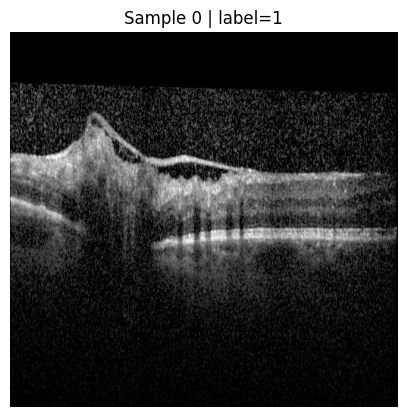

In [22]:
# ── New data loader using CSV_Dataset_eval from util/datasets.py ──────────────
import torch
from torch.utils.data import Subset, DataLoader
from util.datasets import CSV_Dataset_eval, build_transform, build_transform_mask

class _Args:
    """Minimal args namespace required by build_transform / build_transform_mask."""
    input_size = 224
    color_jitter = None
    aa = None
    reprob = 0.0
    remode = 'pixel'
    recount = 1
    train_no_aug = True      # no augmentation for eval
    add_mask = True          # mask images to retinal region (matches IMG_MASK=True)
    output_mask = True       # return multiclass layer mask tensor
    thickness_dir = Thickness_DIR

_args = _Args()
_eval_transform = build_transform('test', _args)   # same eval transform as training
_mask_transform = build_transform_mask(_args)

v5_dataset_dir = "/orange/ruogu.fang/tienyuchang/OCTRFF_Data/data/UF-cohort/IRB2024_v5/split/tune5-eval5/"
_csv_path = os.path.join(v5_dataset_dir, "DME_binary_all_split.csv")
_img_dir  = "/orange/ruogu.fang/tienyuchang/IRB2024_imgs_paired/"

# CSV_Dataset_eval filters by 'split' column if present; otherwise uses all rows.
# is_train='test' selects the test split when available.
_full_test = CSV_Dataset_eval(
    csv_file=_csv_path,
    img_dir=_img_dir,
    is_train='test',
    transfroms=_eval_transform,
    modality='OCT',
    add_mask=True,
    output_mask=True,
    mask_transforms=_mask_transform,
    thickness_dir=Thickness_DIR,
)
print(f"Test split size: {len(_full_test)}")

# Select first N_TEST_SAMPLES
_n = min(N_TEST_SAMPLES, len(_full_test))
test_dataset = Subset(_full_test, list(range(_n)))
print(f"Using {_n} samples for evaluation")

# ── Helper: iterate test_dataset and collect PIL images + tensors ──────────────
def load_test_samples_from_dataset(dataset, img_dir):
    """
    Returns parallel lists matching the old load_sample_data() contract
    plus the pre-built image tensors and mask tensors.

    Returns:
        pil_images    : list of PIL.Image (masked, RGB) — for visualization
        labels        : list of int
        filenames     : list of str (stem of img_path, no extension)
        mask_slices   : list of np.ndarray (L, W) layer boundaries OR None
        img_tensors   : list of torch.Tensor (1, C, H, W) — ready for model
        mask_tensors  : list of np.ndarray (H, W) uint8, multiclass layer labels
    """
    pil_images, labels, filenames, mask_slices, img_tensors, mask_tensors = [], [], [], [], [], []

    # Access underlying CSV_Dataset_eval to get thickness info
    base_ds = dataset.dataset if isinstance(dataset, Subset) else dataset

    for i in range(len(dataset)):
        img_t, label, _, rel_path, mask_t = dataset[i]

        # Reconstruct full image path to reload PIL
        full_path = os.path.join(img_dir, rel_path)
        try:
            pil_img = Image.open(full_path).convert('RGB')
        except Exception:
            pil_img = None

        # Filename stem (e.g. "foldername_13")
        fname = os.path.splitext(os.path.basename(rel_path))[0]

        # Recover mask_slice (L, W) from the base dataset's annotation row
        mask_slice_arr = None
        try:
            # map Subset index back to base dataset index
            base_idx = dataset.indices[i] if isinstance(dataset, Subset) else i
            sample = base_ds.samples[base_idx]  # (img_name, label_idx, mask_name)
            mask_name = sample[2]
            if mask_name:
                mask_path = os.path.join(Thickness_DIR, mask_name)
                mask_full = np.load(mask_path)   # (L, slice_num, W)
                slice_idx = int(os.path.basename(sample[0]).split("_")[-1].split(".")[0])
                mask_slice_arr = mask_full[:, slice_idx, :]
        except Exception as e:
            pass

        # Convert mask tensor to numpy (H, W) uint8
        mask_np = mask_t.squeeze(0).numpy().astype(np.uint8) if mask_t is not None else None

        pil_images.append(pil_img)
        labels.append(label)
        filenames.append(fname)
        mask_slices.append(mask_slice_arr)
        img_tensors.append(img_t.unsqueeze(0))   # (1,C,H,W)
        mask_tensors.append(mask_np)

    return pil_images, labels, filenames, mask_slices, img_tensors, mask_tensors

dme_imgs, dme_labels, dme_img_names, dme_mask_slices, dme_img_tensors, dme_mask_tensors = \
    load_test_samples_from_dataset(test_dataset, _img_dir)

print(f"Loaded {len(dme_imgs)} samples")
print(f"Label distribution: {dict(zip(*np.unique(dme_labels, return_counts=True)))}")
# Sanity-check first sample
if dme_imgs[0] is not None:
    plt.figure(figsize=(5,5))
    plt.imshow(dme_imgs[0])
    plt.title(f"Sample 0 | label={dme_labels[0]}")
    plt.axis('off')
    plt.show()

# Model and XAI

In [15]:

# Load trained models function
def load_trained_model(task, model_name, input_size=224, nb_classes=2):
    """Load a trained model for a specific task"""
    model, processor = get_model(task, model_name, input_size, nb_classes)
    
    # Load model weights based on task and model
    if task == 'ADCon':
        model_paths = ADCon_finetuned
    elif task == 'DME':
        if IMG_MASK or HEATMAP_MASK:
            model_paths = DME_finetuned_masked
        else:
            model_paths = DME_finetuned
    else:
        print(f"Unknown task: {task}")
        model.eval()
        return model, processor
    
    model_idx = Model_list.index(model_name)
    model_dir = model_paths[model_idx]
    model_path = os.path.join(Model_root, model_dir, Model_fname)
    
    # Load finetuned model if specified (following main_XAI_evaluation.py pattern)
    if model_path and model_path != '':
        if os.path.exists(model_path):
            try:
                # Load checkpoint
                if model_path.startswith('https'):
                    checkpoint = torch.hub.load_state_dict_from_url(
                        model_path, map_location='cpu', check_hash=True)
                else:
                    checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
                
                # Extract model state dict
                if 'model' in checkpoint:
                    checkpoint_model = checkpoint['model']
                else:
                    checkpoint_model = checkpoint
                
                # Load with strict=False to handle potential mismatches
                model.load_state_dict(checkpoint_model, strict=False)
                print(f"Resume checkpoint {model_path} for {model_name} on {task}")
                
            except Exception as e:
                print(f"Error loading model {model_name} for {task}: {e}")
                print("Using pretrained weights instead")
        else:
            print(f"Model path not found: {model_path}")
            print(f"Using pretrained weights for {model_name} on {task}")
    else:
        raise ValueError(f"No checkpoint specified for {model_name} on {task}, using pretrained weights")
    
    model.eval()
    return model, processor

#test
'''
model_list = []
for model_name in Model_list:
    model, processor = load_trained_model('DME', model_name, 224)
    print(type(model))
    model_list.append(model)
'''

"\nmodel_list = []\nfor model_name in Model_list:\n    model, processor = load_trained_model('DME', model_name, 224)\n    print(type(model))\n    model_list.append(model)\n"

In [25]:
# XAI Methods Implementation
class XAIGenerator:
    def __init__(self, model, model_name, input_size=224):
        self.model = model
        self.model_name = model_name
        self.input_size = input_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.xai_list = ['Attention', 'TransformerAttribution', 'RISE', 'GradCAM', 'ScoreCAM', 'HiResCAM', 'GradCAMPlusPlus']
        
        # Initialize XAI methods
        self.init_xai_methods()
    
    def get_model_specific_config(self):
        """Get model-specific configuration for XAI methods"""
        config = {
            'patch_size': 14,
            'gpu_batch': 1,
            'attention_layers': 12
        }
        
        # Model-specific configurations
        if 'resnet' in self.model_name.lower():
            config.update({
                'patch_size': 7,  # ResNet has different spatial resolution
                'gpu_batch': 10,  # ResNet can handle larger batches
            })
        elif 'efficientnet' in self.model_name.lower():
            config.update({
                'patch_size': 7,  # EfficientNet spatial resolution
                'gpu_batch': 10,
            })
        elif 'vit' in self.model_name.lower():
            config.update({
                'patch_size': 16,  # ViT patch size
                'gpu_batch': 10,
                'attention_layers': 12,  # Standard ViT-Base layers
            })
        elif 'retfound' in self.model_name.lower():
            config.update({
                'patch_size': 16,  # RETFound uses ViT architecture
                'gpu_batch': 10,
                'attention_layers': 12,
            })
        
        return config
    
    def init_xai_methods(self):
        """Initialize all XAI methods with model-specific configurations"""
        config = self.get_model_specific_config()
        
        # Attention Maps (only for ViT-based models)
        if 'vit' in self.model_name.lower() or 'retfound' in self.model_name.lower():
            self.attention = Attention_Map(
                self.model, 
                self.model_name, 
                self.input_size, 
                N=config['attention_layers'],
                use_rollout=True,
                print_layers=False  # Disable layer printing to avoid issues
            )
            print(f"✓ Attention initialized for {self.model_name} (layers: {config['attention_layers']})")
            # TransformerAttribution (gradient-weighted attention rollout)
            self.transformer_attribution = TFAttribution(
                self.model,
                self.model_name,
                self.input_size,
                N=config['attention_layers'],
                device=self.device,
            )
            print(f"✓ TransformerAttribution initialized for {self.model_name} (layers: {config['attention_layers']})")
        else:
            self.attention = None
            print(f"⚠ Attention skipped for {self.model_name} (not a transformer model)")
            self.transformer_attribution = None
            print(f"⚠ TransformerAttribution skipped for {self.model_name} (not a transformer model)")
        
        # GradCAM with model-specific config
        self.gradcam = PytorchCAM(
            self.model, 
            self.model_name, 
            self.input_size, 
            patch_size=config['patch_size'],
            method=GradCAM
        )
        print(f"✓ GradCAM initialized for {self.model_name} (patch_size: {config['patch_size']})")
        
        # ScoreCAM with model-specific config
        self.scorecam = PytorchCAM(
            self.model, 
            self.model_name, 
            self.input_size, 
            patch_size=config['patch_size'],
            method=ScoreCAM
        )
        print(f"✓ ScoreCAM initialized for {self.model_name} (patch_size: {config['patch_size']})")
        
        # HiResCAM with model-specific config
        self.hirescam = PytorchCAM(
            self.model, 
            self.model_name, 
            self.input_size, 
            patch_size=config['patch_size'],
            method=HiResCAM
        )
        print(f"✓ HiResCAM initialized for {self.model_name} (patch_size: {config['patch_size']})")
        
        # GradCAMPlusPlus with model-specific config
        self.gardcamplusplus = PytorchCAM(
            self.model, 
            self.model_name, 
            self.input_size, 
            patch_size=config['patch_size'],
            method=GradCAMPlusPlus
        )
        print(f"✓ GradCAMPlusPlus initialized for {self.model_name} (patch_size: {config['patch_size']})")
        
        # RISE with model-specific batch size
        # Reduce batch for memory-heavy models
        self.rise = None
        rise_batch = config['gpu_batch']
        self.rise = RISEBatch(
            self.model, 
            input_size=(self.input_size, self.input_size), 
            gpu_batch=rise_batch,
            N=10,
            n_class = 2
        )
        print(f"✓ RISE initialized for {self.model_name} (gpu_batch: {rise_batch})")
        
        self.lrp = None  # Will implement if model supports it
    
    def generate_gradcam(self, image_tensor, target_class=None):
        """Generate GradCAM heatmap"""
        if self.gradcam is None:
            return None
        self.model.zero_grad(set_to_none=True)
        image_tensor = image_tensor.to(self.device)
        if target_class is None:
            # Get predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor)
                target_class = outputs.argmax(dim=1).item()
        targets = [ClassifierOutputTarget(target_class)]
        heatmap = self.gradcam(image_tensor, targets)
        print(heatmap.shape)
        if hasattr(self.gradcam, "remove_hooks"):
            self.gradcam.remove_hooks()
        return heatmap[0] if len(heatmap) > 0 else None
    
    def generate_scorecam(self, image_tensor, target_class=None):
        """Generate ScoreCAM heatmap"""
        if self.scorecam is None:
            return None
        self.model.zero_grad(set_to_none=True)
        image_tensor = image_tensor.to(self.device)
        if target_class is None:
            # Get predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor)
                target_class = outputs.argmax(dim=1).item()

        targets = [ClassifierOutputTarget(target_class)]
        heatmap = self.scorecam(image_tensor, targets)
        print(heatmap.shape)
        if hasattr(self.scorecam, "remove_hooks"):
            self.scorecam.remove_hooks()
        return heatmap[0] if len(heatmap) > 0 else None
    
    def generate_gardcamplusplus(self, image_tensor, target_class=None):
        """Generate gardcamplusplus heatmap"""
        if self.gardcamplusplus is None:
            return None
        self.model.zero_grad(set_to_none=True)
        image_tensor = image_tensor.to(self.device)
        if target_class is None:
            # Get predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor)
                target_class = outputs.argmax(dim=1).item()

        targets = [ClassifierOutputTarget(target_class)]
        heatmap = self.gardcamplusplus(image_tensor, targets)
        print(heatmap.shape)
        if hasattr(self.gardcamplusplus, "remove_hooks"):
            self.gardcamplusplus.remove_hooks()
        return heatmap[0] if len(heatmap) > 0 else None
    
    def generate_hirescam(self, image_tensor, target_class=None):
        """Generate hirescam heatmap"""
        if self.hirescam is None:
            return None
        self.model.zero_grad(set_to_none=True)
        image_tensor = image_tensor.to(self.device)
        if target_class is None:
            # Get predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor)
                target_class = outputs.argmax(dim=1).item()

        targets = [ClassifierOutputTarget(target_class)]
        heatmap = self.hirescam(image_tensor, targets)
        print(heatmap.shape)
        if hasattr(self.hirescam, "remove_hooks"):
            self.hirescam.remove_hooks()
        return heatmap[0] if len(heatmap) > 0 else None
    
    def generate_rise(self, image_tensor, target_class=None):
        """Generate RISE heatmap"""
        if self.rise is None:
            return None
        image_tensor = image_tensor.to(self.device)

        if target_class is None:
            # Get predicted class
            with torch.no_grad():
                outputs = self.model(image_tensor)
                target_class = outputs.argmax(dim=1).item()

        heatmap = self.rise(image_tensor,[target_class])
        print(heatmap.shape)
        return heatmap[0] if heatmap is not None else None

    def generate_attention(self, image_tensor, target_class=None):
        """Generate Attention heatmap"""
        if self.attention is None:
            return None
        image_tensor = image_tensor.to(self.device)
        attention_map = self.attention(image_tensor)
        return attention_map[0] if attention_map is not None else None

    def generate_transformer_attribution(self, image_tensor, target_class=None):
        """Generate TransformerAttribution heatmap (attention x gradient rollout)."""
        if self.transformer_attribution is None:
            return None
        image_tensor = image_tensor.to(self.device)
        if target_class is None:
            with torch.no_grad():
                outputs = self.model(image_tensor)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                target_class = logits.argmax(dim=1).item()
        targets = torch.tensor([int(target_class)], device=self.device)
        self.model.zero_grad()
        heatmap = self.transformer_attribution(inputs=image_tensor, targets=targets)
        # heatmap: np.ndarray (B, H, W), already normalized [0,1]
        return heatmap[0] if heatmap is not None else None
    
    def generate_all_heatmaps(self, image_tensor, target_class=None, xai_name=None):
        """Generate all available heatmaps for an image (safe, no hook interference)"""
        #['Attention', 'RISE', 'GradCAM', 'ScoreCAM']
        if xai_name==None:
            xai_names = self.xai_list
        elif isinstance(xai_name,list):
            xai_names = xai_name
        else:
            xai_names = [xai_name]
        heatmaps = {}
        attention_map, rise_map, gradcam_map, scorecam_map = None, None, None, None
        hirescam_map, gardcamplusplus_map, transformer_attribution_map = None, None, None
        # Attention
        if 'Attention' in xai_names:
            attention_map = self.generate_attention(image_tensor)
        if attention_map is not None:
            heatmaps['Attention'] = attention_map

        # TransformerAttribution
        if 'TransformerAttribution' in xai_names:
            transformer_attribution_map = self.generate_transformer_attribution(image_tensor, target_class)
        if transformer_attribution_map is not None:
            heatmaps['TransformerAttribution'] = transformer_attribution_map

        # RISE (chunk-based forward, 不依賴 hooks)
        if 'RISE' in xai_names:
            rise_map = self.generate_rise(image_tensor, target_class)
        if rise_map is not None:
            heatmaps['RISE'] = rise_map

        # GradCAM（需要梯度 + hooks）
        if 'GradCAM' in xai_names:
            gradcam_map = self.generate_gradcam(image_tensor, target_class)
        if gradcam_map is not None:
            heatmaps['GradCAM'] = gradcam_map

        # ScoreCAM
        if 'ScoreCAM' in xai_names:
            scorecam_map = self.generate_scorecam(image_tensor, target_class)
        if scorecam_map is not None:
            heatmaps['ScoreCAM'] = scorecam_map
        #['Attention', 'RISE', 'GradCAM', 'ScoreCAM', 'HiResCAM', 'GradCAMPlusPlus']
        # GradCAMPlusPlus
        if 'GradCAMPlusPlus' in xai_names:
            gardcamplusplus_map = self.generate_gardcamplusplus(image_tensor, target_class)
        if gardcamplusplus_map is not None:
            heatmaps['GradCAMPlusPlus'] = gardcamplusplus_map
        
        # HiResCAM
        if 'HiResCAM' in xai_names:
            hirescam_map = self.generate_hirescam(image_tensor, target_class)
        if hirescam_map is not None:
            heatmaps['HiResCAM'] = hirescam_map

        return heatmaps

#test
'''
for model_name in Model_list:
    model, processor = load_trained_model('DME', model_name, 224)
    XAIGenerator(model, model_name)
'''

"\nfor model_name in Model_list:\n    model, processor = load_trained_model('DME', model_name, 224)\n    XAIGenerator(model, model_name)\n"

# Run Heatmap

In [11]:
# Visualization functions
def _build_binary_mask(mask_slice, heatmap):
    if isinstance(heatmap, Image.Image):
        heatmap = np.array(heatmap)
    binary_mask = np.zeros((heatmap.shape[0],heatmap.shape[1]), dtype=np.uint8)
    for i in range(mask_slice.shape[0]-1):
        upper = mask_slice[i].astype(int)
        lower = mask_slice[i+1].astype(int)
        for x in range(heatmap.shape[1]):
            binary_mask[upper[x]:lower[x], x] = 1
    return binary_mask
def masked_heatmap_func(heatmap, mask_slice):
    if heatmap is None:
        return None
    binary_mask = _build_binary_mask(mask_slice, heatmap)

    # 套用 mask (把 mask=0 的地方設為 0)
    masked_heatmap = heatmap.copy()
    masked_heatmap[binary_mask == 0] = 0

    return masked_heatmap

def add_layer_line(overlay, mask_slice, width=1, cmap_name="rainbow"):
    # Convert to PIL.Image if needed
    if isinstance(overlay, np.ndarray):
        if overlay.dtype != np.uint8:
            overlay = np.clip(overlay * 255, 0, 255).astype(np.uint8)
        overlay_img = Image.fromarray(overlay)
    else:
        overlay_img = overlay.convert("RGB")
    draw = ImageDraw.Draw(overlay_img)
    n_layers, W = mask_slice.shape
    xs = np.arange(W)
    # Generate rainbow colors for each layer
    cmap = plt.get_cmap(cmap_name)
    colors = (np.array([cmap(i / max(1, n_layers - 1))[:3] for i in range(n_layers)]) * 255).astype(int)
    # Draw each layer line
    for i in range(n_layers):
        ys = np.nan_to_num(mask_slice[i].astype(float), nan=0.0)
        ys = np.clip(ys, 0, overlay_img.height - 1)
        points = list(zip(xs, ys))
        color = tuple(colors[i])
        draw.line(points, fill=color, width=width)

    return overlay_img

def normalize_heatmap(heatmap):
    """Normalize heatmap to 0-1 range"""
    if heatmap is None:
        return None
    
    heatmap = np.array(heatmap)
    if heatmap.max() == heatmap.min():
        return np.zeros_like(heatmap)
    
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

def overlay_heatmap_on_image(image, heatmap, mask_slice = None, alpha=0.4, colormap='jet'):
    """Overlay heatmap on original image"""
    
    if heatmap is None:
        return np.array(image)
    
    # Normalize heatmap
    heatmap_norm = normalize_heatmap(heatmap)
    
    # Resize heatmap to match image size
    if isinstance(image, Image.Image):
        image_array = np.array(image)
        image_size = image.size
    else:
        image_array = image
        image_size = (image.shape[1], image.shape[0])
    print("image original")
    print(image_array.shape, heatmap.shape)
    heatmap_resized = cv2.resize(heatmap_norm, image_size)
    
    if HEATMAP_MASK and mask_slice is not None:
        heatmap_resized = masked_heatmap_func(heatmap_resized, mask_slice)
    
    # Apply colormap
    cmap = plt.get_cmap(colormap)
    heatmap_colored = cmap(heatmap_resized)
    print(heatmap_colored.shape)
    heatmap_colored = heatmap_colored[:, :, :3]  # Remove alpha channel
    
    # Normalize image
    image_norm = image_array.astype(np.float32) / 255.0
    
    # Overlay
    print("image norm")
    print(image_norm.shape, heatmap_colored.shape)
    overlay = alpha * heatmap_colored + (1 - alpha) * image_norm
    overlay = np.clip(overlay, 0, 1)
    
    return (overlay * 255).astype(np.uint8), heatmap_resized

In [12]:
from util.evaluation import RelevanceMetric
rel_metric = RelevanceMetric()
rank_metric = RelevanceMetric(output_type='rank')
# Updated function with new directory structure for heatmap saving
def generate_comprehensive_heatmaps_v2(num_samples=3,task_list=Task_list,model_list=Model_list,img_size_list=Model_image_size_list,XAI_list=None,heatmap_dir="./heatmap_results",preloaded=None):
    """
    preloaded: optional dict keyed by task name with keys:
        'images', 'labels', 'filenames', 'mask_slices', 'img_tensors'
    If provided, skips load_sample_data and preprocess_image for that task.
    """
    
    results = {}
    #input_size = 224
    if XAI_list==None:
        XAI_list = ['Attention', 'RISE', 'GradCAM', 'ScoreCAM', 'HiResCAM', 'GradCAMPlusPlus']
    
    print("Starting comprehensive heatmap generation...")
    print(f"Tasks: {task_list}")
    print(f"Models: {model_list}")
    print(f"XAI: {XAI_list}")
    print(f"Samples per task: {num_samples}")
    
    for task in task_list:
        print(f"\n=== Processing Task: {task} ===")
        results[task] = {}
        
        # Load sample data for this task (now returns filenames too)
        if preloaded and task in preloaded:
            images      = preloaded[task]['images']
            labels      = preloaded[task]['labels']
            filenames   = preloaded[task]['filenames']
            mask_slices = preloaded[task]['mask_slices']
            _preloaded_tensors = preloaded[task].get('img_tensors', None)
            print(f"Using preloaded data: {len(images)} samples")
        else:
            _preloaded_tensors = None
            try:
                images, labels, filenames, mask_slices = load_sample_data(task, num_samples)
                print(f"Loaded {len(images)} images for {task}")
            except Exception as e:
                print(f"Error loading data for {task}: {e}")
                continue
        out_df = []
        for model_name, input_size in zip(model_list, img_size_list):
            print(f"\n--- Processing Model: {model_name} ---")
            # Load trained model
            model, processor = load_trained_model(task, model_name, input_size)
            # Initialize XAI generator
            xai_generator = XAIGenerator(model, model_name, input_size)
            # Store results for this model
            results[task][model_name] = {
                'images': filenames,
                'labels': labels,
                "mask_slices": mask_slices
            }
            # Process each image with filename
            for idx, (image, label, filename, mask_slice) in enumerate(zip(images, labels, filenames, mask_slices)):
                #print(f"Processing image {idx+1}/{len(images)} (Label: {label}, File: {filename})")
                # Preprocess image
                if _preloaded_tensors is not None:
                    image_tensor = _preloaded_tensors[idx].to('cuda' if torch.cuda.is_available() else 'cpu')
                else:
                    image_tensor = preprocess_image(image, processor, input_size)
                # Generate all heatmaps for this image
                
                #heatmaps = xai_generator.generate_all_heatmaps(image_tensor, target_class=label)
                #results[task][model_name]['heatmaps'].append(heatmaps)
                for xai_name in XAI_list:
                    heatmap_dict = xai_generator.generate_all_heatmaps(image_tensor, target_class=label, xai_name=xai_name)
                    heatmap = heatmap_dict.get(xai_name,None)
                    if heatmap is None:
                        continue
                    print("XAI & heatmap: ",xai_name, heatmap.shape)
                    heatmap = heatmap + 1e-9
                    overlay, heatmap_resized = overlay_heatmap_on_image(image, heatmap, mask_slice)
                    binary_mask = _build_binary_mask(mask_slice, overlay) if mask_slice is not None else None
                    print(binary_mask.shape)
                    '''
                    plt.imshow(binary_mask, cmap='gray')
                    plt.axis('off')
                    plt.show()
                    '''
                    mass_acc = rel_metric(images,heatmap_resized, binary_mask)
                    rank_acc = rank_metric(images,heatmap_resized, binary_mask)
                    #print(f"Image: {filename}, XAI: {xai_name}, Relevance Mass Accuracy: {mass_acc:.4f}")
                    if DRAW_LAYER:
                        overlay = add_layer_line(overlay, mask_slice)
                    # overlay is np.uint8 HxWx3 per implementation
                    # Create directory structure: ./heatmap_results/<task_name>/<label_idx>/<image_name>/<baselinemodel>/<XAI>.jpg
                    save_dir = Path(heatmap_dir) / task / str(label) / filename / model_name
                    save_dir.mkdir(parents=True, exist_ok=True)
                    out_path = save_dir / f"{xai_name}.jpg"
                    try:
                        if not isinstance(overlay, Image.Image):
                            overlay = Image.fromarray(overlay)
                        overlay.save(out_path, format='JPEG', quality=95)
                        # Save the heatmap as numpy array
                        np.save(save_dir / f"{xai_name}.npy", heatmap)
                    except Exception as e:
                        print(f"Failed to save {out_path}: {e}")
                    out_df.append({
                        'task': task,
                        'image_name': filename,
                        'label': label,
                        'output_path': str(out_path),
                        'model_name': model_name,
                        'xai_method': xai_name,
                        'relevance_mass_accuracy': mass_acc,
                        'relevance_rank_accuracy': rank_acc
                    })
            print(f"Completed {model_name} for {task}")
            #delete after finish
            del xai_generator, heatmap_dict, image_tensor
        # Save out_df to CSV
        df = pd.DataFrame(out_df)
        df.to_csv(Path(heatmap_dir) / f"{task}_results.csv", index=False)
    return results

In [17]:
#%%capture output

print("=== RETFound TransformerAttribution Heatmap Generation ===")

heatmap_results_v2 = generate_comprehensive_heatmaps_v2(
    num_samples=N_TEST_SAMPLES,
    task_list=['DME'],
    model_list=['RETFound_mae'],
    img_size_list=[224],
    XAI_list=['Attention', 'TransformerAttribution'],
    heatmap_dir="./heatmap_results_retfound_ta",
    preloaded={
        'DME': {
            'images':      dme_imgs,
            'labels':      dme_labels,
            'filenames':   dme_img_names,
            'mask_slices': dme_mask_slices,
            'img_tensors': dme_img_tensors,
        }
    }
)

=== RETFound TransformerAttribution Heatmap Generation ===
Starting comprehensive heatmap generation...
Tasks: ['DME']
Models: ['RETFound_mae']
XAI: ['Attention', 'TransformerAttribution']
Samples per task: 200

=== Processing Task: DME ===
Using preloaded data: 200 samples

--- Processing Model: RETFound_mae ---
Model path not found: /orange/ruogu.fang/tienyuchang/RETfound_results/DME_binary_all_split-IRB2024_v5-all-microsoft/resnet-50-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/checkpoint-best.pth
Using pretrained weights for RETFound_mae on DME
✓ Attention initialized for RETFound_mae (layers: 12)
✓ TransformerAttribution initialized for RETFound_mae (layers: 12)
Resolved target layer for GradCAM: Block
✓ GradCAM initialized for RETFound_mae (patch_size: 16)
Resolved target layer for GradCAM: Block
✓ ScoreCAM initialized for RETFound_mae (patch_size: 16)
Resolved target layer for GradCAM: Block
✓ HiResCAM initialized for RETFound_mae (patch_size: 16)
Reso

In [ ]:
#output.show()

In [18]:
# ── Case study: select N_CASES samples ────────────────────────────────────────
import random

# Select N_CASES samples: try to balance positive/negative labels
pos_idx = [i for i, l in enumerate(dme_labels) if l == 1]
neg_idx = [i for i, l in enumerate(dme_labels) if l == 0]

random.seed(42)
n_pos = N_CASES // 2
n_neg = N_CASES - n_pos
case_indices = (
    random.sample(pos_idx, min(n_pos, len(pos_idx))) +
    random.sample(neg_idx, min(n_neg, len(neg_idx)))
)
case_indices = sorted(case_indices)
print(f"Case study indices: {case_indices}")
print(f"Labels: {[dme_labels[i] for i in case_indices]}")

Case study indices: [7, 23, 30, 32, 54, 63, 74, 151, 163, 193]
Labels: [1, 0, 0, 1, 0, 1, 1, 0, 0, 1]


Model path not found: /orange/ruogu.fang/tienyuchang/RETfound_results/DME_binary_all_split-IRB2024_v5-all-microsoft/resnet-50-OCT-bs16ep50lr5e-4optadamw-defaulteval-trsub0---add_mask---train_no_aug/checkpoint-best.pth
Using pretrained weights for RETFound_mae on DME
✓ Attention initialized for RETFound_mae (layers: 12)
✓ TransformerAttribution initialized for RETFound_mae (layers: 12)
Resolved target layer for GradCAM: Block
✓ GradCAM initialized for RETFound_mae (patch_size: 16)
Resolved target layer for GradCAM: Block
✓ ScoreCAM initialized for RETFound_mae (patch_size: 16)
Resolved target layer for GradCAM: Block
✓ HiResCAM initialized for RETFound_mae (patch_size: 16)
Resolved target layer for GradCAM: Block
✓ GradCAMPlusPlus initialized for RETFound_mae (patch_size: 16)
✓ RISE initialized for RETFound_mae (gpu_batch: 10)
{'Attention': array([[0.09114366, 0.09114366, 0.09114366, ..., 0.09220725, 0.09220725,
        0.09220725],
       [0.09114366, 0.09114366, 0.09114366, ..., 0.092

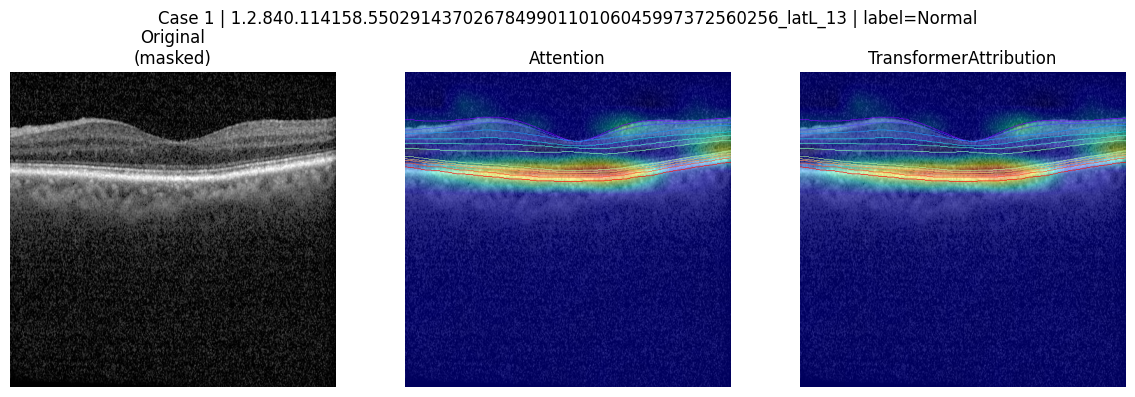

Saved: case_studies/case_01_label0_1.2.840.114158.55029.png
{'Attention': array([[0.11240658, 0.11240658, 0.11240658, ..., 0.11318745, 0.11318745,
        0.11318745],
       [0.11240658, 0.11240658, 0.11240658, ..., 0.11318745, 0.11318745,
        0.11318745],
       [0.11240658, 0.11240658, 0.11240658, ..., 0.11318745, 0.11318745,
        0.11318745],
       ...,
       [0.11224213, 0.11224213, 0.11224213, ..., 0.11206185, 0.11206185,
        0.11206185],
       [0.11224213, 0.11224213, 0.11224213, ..., 0.11206185, 0.11206185,
        0.11206185],
       [0.11224213, 0.11224213, 0.11224213, ..., 0.11206185, 0.11206185,
        0.11206185]], dtype=float32), 'TransformerAttribution': array([[0.11240658, 0.11240658, 0.11240658, ..., 0.11318695, 0.11318695,
        0.11318695],
       [0.11240658, 0.11240658, 0.11240658, ..., 0.11318695, 0.11318695,
        0.11318695],
       [0.11240658, 0.11240658, 0.11240658, ..., 0.11318695, 0.11318695,
        0.11318695],
       ...,
       [0.112

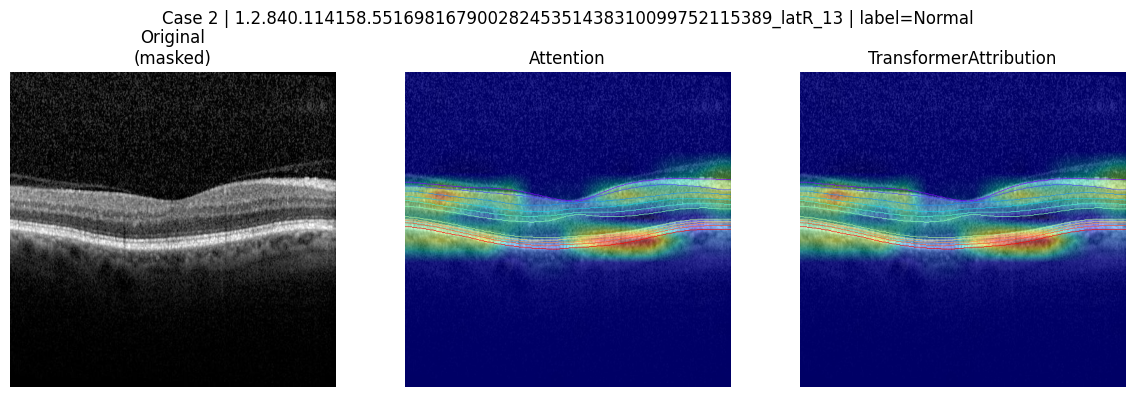

Saved: case_studies/case_02_label0_1.2.840.114158.55169.png
{'Attention': array([[0.18008342, 0.18008342, 0.18008342, ..., 0.18117899, 0.18117899,
        0.18117899],
       [0.18008342, 0.18008342, 0.18008342, ..., 0.18117899, 0.18117899,
        0.18117899],
       [0.18008342, 0.18008342, 0.18008342, ..., 0.18117899, 0.18117899,
        0.18117899],
       ...,
       [0.17970447, 0.17970447, 0.17970447, ..., 0.17974728, 0.17974728,
        0.17974728],
       [0.17970447, 0.17970447, 0.17970447, ..., 0.17974728, 0.17974728,
        0.17974728],
       [0.17970447, 0.17970447, 0.17970447, ..., 0.17974728, 0.17974728,
        0.17974728]], dtype=float32), 'TransformerAttribution': array([[0.18008374, 0.18008374, 0.18008374, ..., 0.18117929, 0.18117929,
        0.18117929],
       [0.18008374, 0.18008374, 0.18008374, ..., 0.18117929, 0.18117929,
        0.18117929],
       [0.18008374, 0.18008374, 0.18008374, ..., 0.18117929, 0.18117929,
        0.18117929],
       ...,
       [0.179

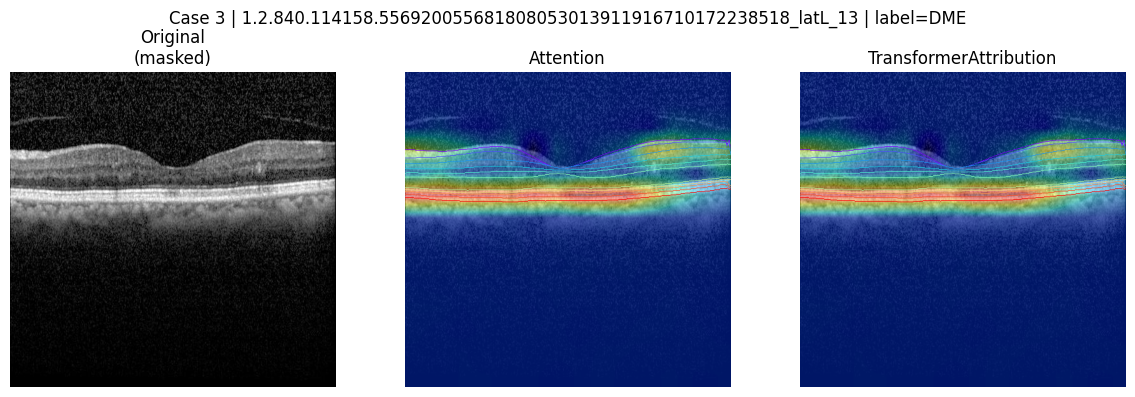

Saved: case_studies/case_03_label1_1.2.840.114158.55692.png
{'Attention': array([[0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       [0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       [0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       ...,
       [0.1703793 , 0.1703793 , 0.1703793 , ..., 0.17019585, 0.17019585,
        0.17019585],
       [0.1703793 , 0.1703793 , 0.1703793 , ..., 0.17019585, 0.17019585,
        0.17019585],
       [0.1703793 , 0.1703793 , 0.1703793 , ..., 0.17019585, 0.17019585,
        0.17019585]], dtype=float32), 'TransformerAttribution': array([[0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       [0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       [0.17036039, 0.17036039, 0.17036039, ..., 0.47414458, 0.47414458,
        0.47414458],
       ...,
       [0.170

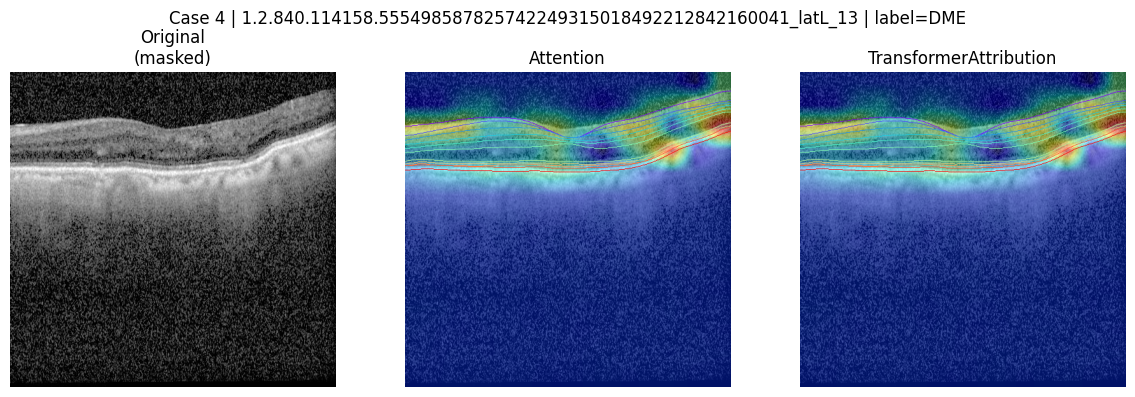

Saved: case_studies/case_04_label1_1.2.840.114158.55549.png
{'Attention': array([[0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       [0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       [0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       ...,
       [0.04558695, 0.04558695, 0.04558695, ..., 0.04541461, 0.04541461,
        0.04541461],
       [0.04558695, 0.04558695, 0.04558695, ..., 0.04541461, 0.04541461,
        0.04541461],
       [0.04558695, 0.04558695, 0.04558695, ..., 0.04541461, 0.04541461,
        0.04541461]], dtype=float32), 'TransformerAttribution': array([[0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       [0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       [0.04579172, 0.04579172, 0.04579172, ..., 0.04671458, 0.04671458,
        0.04671458],
       ...,
       [0.045

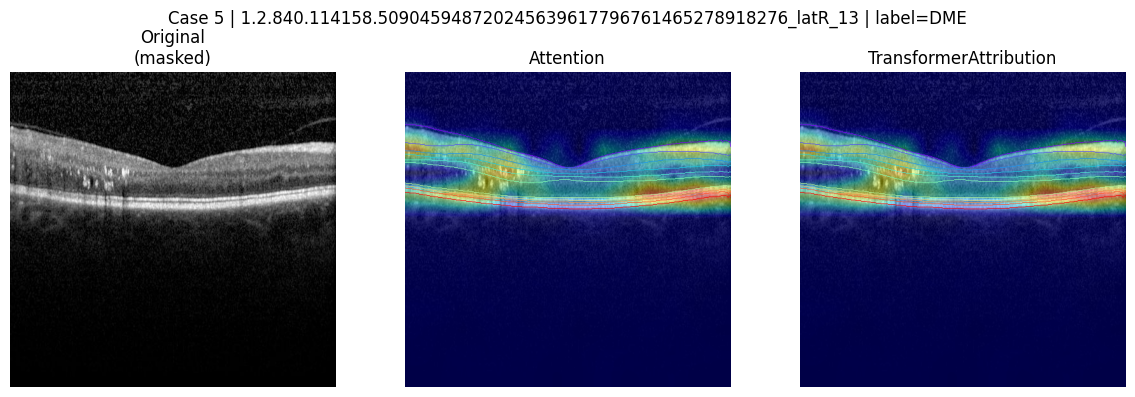

Saved: case_studies/case_05_label1_1.2.840.114158.50904.png
{'Attention': array([[0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       [0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       [0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       ...,
       [0.08746924, 0.08746924, 0.08746924, ..., 0.08657502, 0.08657502,
        0.08657502],
       [0.08746924, 0.08746924, 0.08746924, ..., 0.08657502, 0.08657502,
        0.08657502],
       [0.08746924, 0.08746924, 0.08746924, ..., 0.08657502, 0.08657502,
        0.08657502]], dtype=float32), 'TransformerAttribution': array([[0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       [0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       [0.08706184, 0.08706184, 0.08706184, ..., 0.08800117, 0.08800117,
        0.08800117],
       ...,
       [0.087

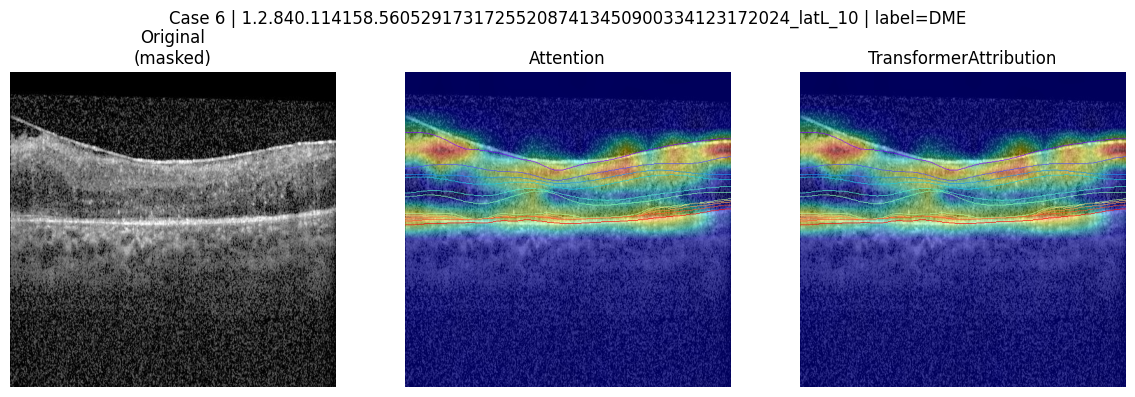

Saved: case_studies/case_06_label1_1.2.840.114158.56052.png
{'Attention': array([[0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       [0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       [0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       ...,
       [0.10451163, 0.10451163, 0.10451163, ..., 0.10450982, 0.10450982,
        0.10450982],
       [0.10451163, 0.10451163, 0.10451163, ..., 0.10450982, 0.10450982,
        0.10450982],
       [0.10451163, 0.10451163, 0.10451163, ..., 0.10450982, 0.10450982,
        0.10450982]], dtype=float32), 'TransformerAttribution': array([[0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       [0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       [0.10487805, 0.10487805, 0.10487805, ..., 0.10574277, 0.10574277,
        0.10574277],
       ...,
       [0.104

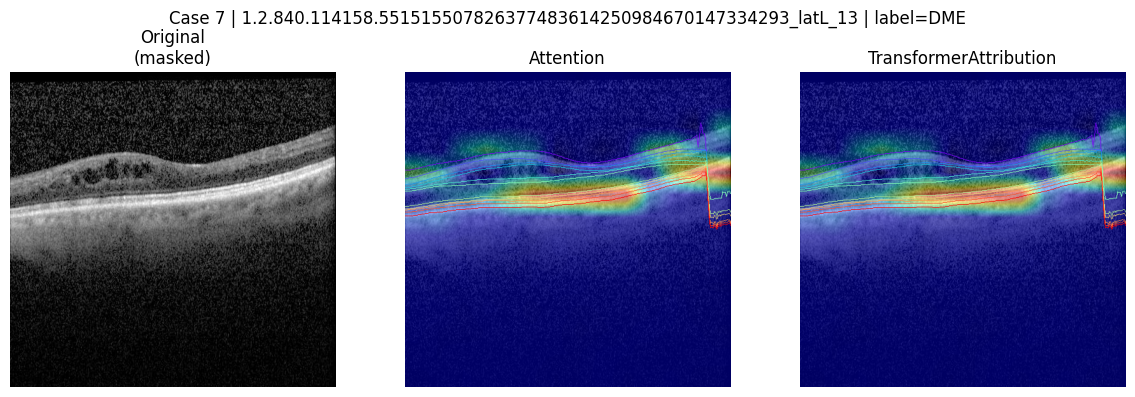

Saved: case_studies/case_07_label1_1.2.840.114158.55151.png
{'Attention': array([[0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       [0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       [0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       ...,
       [0.10222267, 0.10222267, 0.10222267, ..., 0.10252147, 0.10252147,
        0.10252147],
       [0.10222267, 0.10222267, 0.10222267, ..., 0.10252147, 0.10252147,
        0.10252147],
       [0.10222267, 0.10222267, 0.10222267, ..., 0.10252147, 0.10252147,
        0.10252147]], dtype=float32), 'TransformerAttribution': array([[0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       [0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       [0.10294259, 0.10294259, 0.10294259, ..., 0.1037822 , 0.1037822 ,
        0.1037822 ],
       ...,
       [0.102

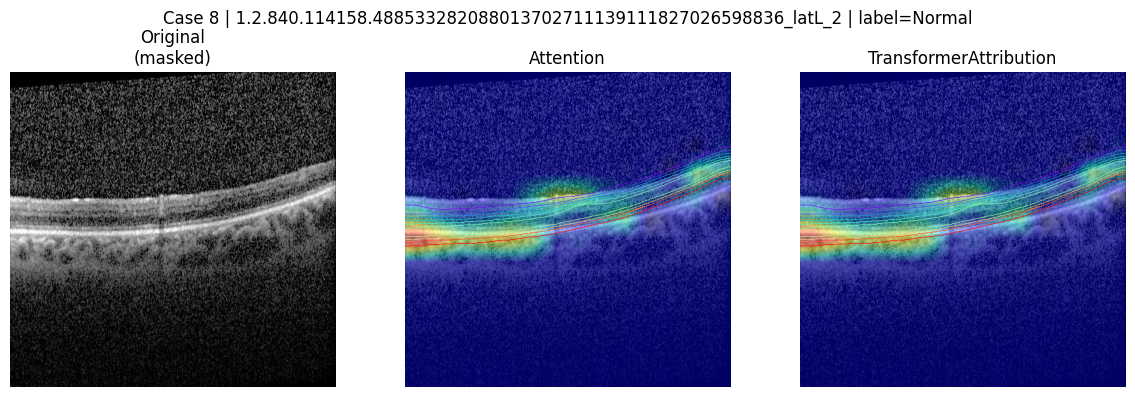

Saved: case_studies/case_08_label0_1.2.840.114158.48853.png
{'Attention': array([[0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       [0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       [0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       ...,
       [0.1444497 , 0.1444497 , 0.1444497 , ..., 0.144567  , 0.144567  ,
        0.144567  ],
       [0.1444497 , 0.1444497 , 0.1444497 , ..., 0.144567  , 0.144567  ,
        0.144567  ],
       [0.1444497 , 0.1444497 , 0.1444497 , ..., 0.144567  , 0.144567  ,
        0.144567  ]], dtype=float32), 'TransformerAttribution': array([[0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       [0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       [0.1447193 , 0.1447193 , 0.1447193 , ..., 0.14560497, 0.14560497,
        0.14560497],
       ...,
       [0.144

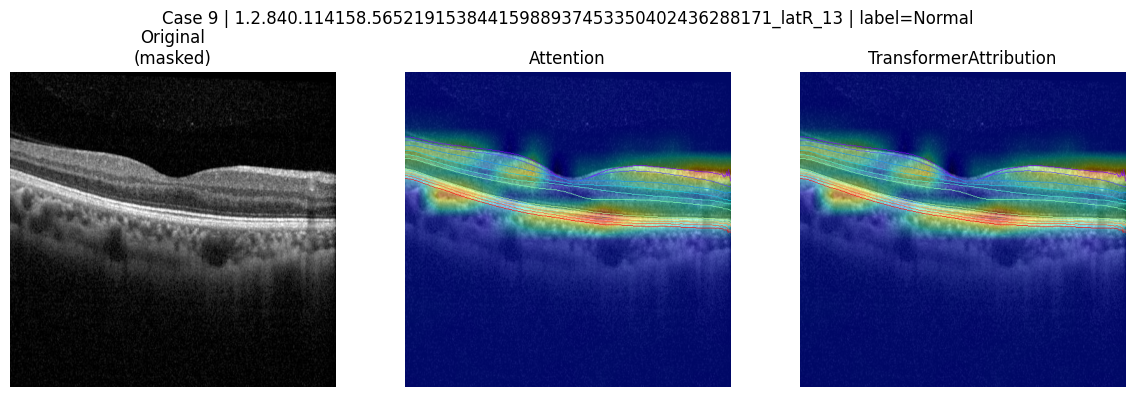

Saved: case_studies/case_09_label0_1.2.840.114158.56521.png
{'Attention': array([[0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       [0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       [0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       ...,
       [0.10161557, 0.10161557, 0.10161557, ..., 0.10169244, 0.10169244,
        0.10169244],
       [0.10161557, 0.10161557, 0.10161557, ..., 0.10169244, 0.10169244,
        0.10169244],
       [0.10161557, 0.10161557, 0.10161557, ..., 0.10169244, 0.10169244,
        0.10169244]], dtype=float32), 'TransformerAttribution': array([[0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       [0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       [0.10202974, 0.10202974, 0.10202974, ..., 0.10286298, 0.10286298,
        0.10286298],
       ...,
       [0.101

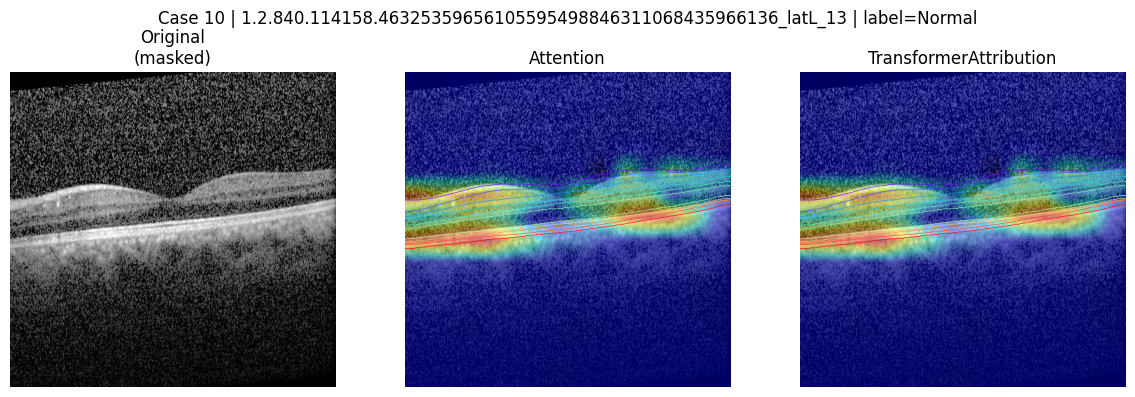

Saved: case_studies/case_10_label0_1.2.840.114158.46325.png
Done — all case studies saved to ./case_studies/


In [ ]:
# ── Case study: generate and display N heatmap grids ──────────────────────────
XAI_CASE_LIST = ['Attention', 'TransformerAttribution']
CASE_STUDY_DIR = Path("./case_studies")
CASE_STUDY_DIR.mkdir(parents=True, exist_ok=True)

# Load RETFound model once
case_model, case_processor = load_trained_model('DME', 'RETFound_mae', 224)
case_xai = XAIGenerator(case_model, 'RETFound_mae', 224)

for case_num, idx in enumerate(case_indices):
    img      = dme_imgs[idx]
    label    = dme_labels[idx]
    fname    = dme_img_names[idx]
    mslice   = dme_mask_slices[idx]
    img_t    = dme_img_tensors[idx]

    # Generate all heatmaps for this case
    heatmap_dict = case_xai.generate_all_heatmaps(img_t, target_class=label,xai_name=XAI_CASE_LIST)
    #print(heatmap_dict)

    n_cols = len(XAI_CASE_LIST) + 1   # +1 for original
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 4, 4))
    fig.suptitle(f"Case {case_num+1} | {fname} | label={'DME' if label==1 else 'Normal'}", fontsize=12)

    # Column 0: original (masked) image
    axes[0].imshow(img)
    axes[0].set_title("Original\n(masked)")
    axes[0].axis('off')

    # Columns 1..N: heatmap overlays
    for col, xai_name in enumerate(XAI_CASE_LIST, start=1):
        heatmap = heatmap_dict[xai_name]
        if heatmap is not None:
            overlay_np, _ = overlay_heatmap_on_image(img, heatmap, mslice)
            if DRAW_LAYER and mslice is not None:
                overlay_pil = add_layer_line(overlay_np, mslice)
                axes[col].imshow(overlay_pil)
            else:
                axes[col].imshow(overlay_np)
            axes[col].set_title(xai_name)
        else:
            axes[col].text(0.5, 0.5, 'N/A', ha='center', va='center',
                           transform=axes[col].transAxes, fontsize=14)
            axes[col].set_title(xai_name)
        axes[col].axis('off')

    plt.tight_layout()
    save_path = CASE_STUDY_DIR / f"case_{case_num+1:02d}_label{label}_{fname[:20]}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

del case_model, case_xai
print("Done — all case studies saved to ./case_studies/")

# Grid Visualize (Not Used)

In [27]:
from tqdm import tqdm

def create_heatmap_grid(results_dict, task,dme_img_names, save_path=None):
    """Create a comprehensive grid visualization of all heatmaps"""
    models = Model_list
    #xai_methods = ['GradCAM', 'ScoreCAM', 'RISE', 'Attention', 'CRP_LXT']
    xai_methods = ['GradCAM', 'ScoreCAM', 'RISE', 'Attention']
    
    # Calculate grid dimensions
    n_models = len(models)
    n_methods = len(xai_methods)
    num_samples = len(results_dict[task][Model_list[0]]['labels'])
    for sample_idx in tqdm(range(num_samples)):
        # Create figure
        fig_width = max(20, n_methods * 4)
        fig_height = max(15, n_models * 3)
        fig, axes = plt.subplots(
            n_models, 
            n_methods + 1,  # +1 for original image
            figsize=(fig_width, fig_height)
        )
        if n_models == 1:
            axes = axes.reshape(1, -1)
        elif len(axes.shape) == 1:
            axes = axes.reshape(-1, 1)
        for model_idx, model in enumerate(models):
            if model not in results_dict[task]:
                continue
            model_results = results_dict[task][model]
            images = model_results['images']
            labels = model_results['labels']
            heatmaps = model_results['heatmaps']
            mask_slices = model_results['mask_slices']
            image = images[sample_idx]
            label = labels[sample_idx]
            sample_heatmaps = heatmaps[sample_idx]
            sample_mask_slice = mask_slices[sample_idx]

            # Original image
            axes[model_idx, 0].imshow(image)
            axes[model_idx, 0].set_title(f'{task}-{model}\nSample {sample_idx+1} (Label: {label})')
            axes[model_idx, 0].axis('off')
            # Heatmaps
            for method_idx, method in enumerate(xai_methods):
                col_idx = method_idx + 1
                
                if method in sample_heatmaps and sample_heatmaps[method] is not None:
                    overlay = overlay_heatmap_on_image(image, sample_heatmaps[method], sample_mask_slice)
                    if DRAW_LAYER:
                        overlay = add_layer_line(overlay, mask_slice)
                    axes[model_idx, col_idx].imshow(overlay)
                    axes[model_idx, col_idx].set_title(f'{method}')
                else:
                    axes[model_idx, col_idx].text(0.5, 0.5, 'N/A', 
                                                ha='center', va='center', 
                                                transform=axes[model_idx, col_idx].transAxes)
                    axes[model_idx, col_idx].set_title(f'{method}')
                axes[model_idx, col_idx].axis('off')
        plt.tight_layout()
        if save_path:
            sample_path = save_path.parent / f"{save_path.stem}_{dme_img_names[sample_idx]}{save_path.suffix}"
            plt.savefig(sample_path, dpi=300, bbox_inches='tight')
            #print(f"Heatmap grid saved to {save_path}")
        plt.close(fig)


In [ ]:
# Create individual task-specific visualizations
def create_task_specific_grids(results_dict, output_dir, dme_img_names):
    """Create separate visualizations for each task"""
    for task in results_dict.keys():
        print(f"Creating visualization for {task}...")
        # Create task-specific results dict
        task_results = {task: results_dict[task]}
        # Create visualization
        task_grid_path = output_dir / task / "heatmap_grid.png"
        create_heatmap_grid(task_results, task, dme_img_names, save_path=task_grid_path)

# Generate task-specific grids
output_dir = Path("./heatmap_results_modelmask") 
create_task_specific_grids(heatmap_results_v2, output_dir, dme_img_names)


# Summaries heatmap value

In [43]:
import xml.etree.ElementTree as ET
def read_grid_center(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    cx = int(float(root.findtext(".//center/x")))
    cz = int(float(root.findtext(".//center/z")))
    return cx, cz

LAYER_LIST = ['ILM (ILM)', 'RNFL-GCL (RNFL-GCL)', 'GCL-IPL (GCL-IPL)', 'IPL-INL (IPL-INL)', 'INL-OPL (INL-OPL)', 'OPL-Henles fiber layer (OPL-HFL)', 'Boundary of myoid and ellipsoid of inner segments (BMEIS)', 'IS/OS junction (IS/OSJ)', 'Inner boundary of OPR (IB_OPR)', 'Inner boundary of RPE (IB_RPE)', 'Outer boundary of RPE (OB_RPE)']

In [44]:
def calculate_layer_statistics(heatmap, mask_slice):
    """
    Divide heatmap into layers based on mask_slice and calculate statistics
    Includes background region (pixels outside all layers)
    
    Args:
        heatmap: 2D numpy array (H, W)
        mask_slice: 2D numpy array (num_layers, W) - layer boundaries
    
    Returns:
        list: Statistics for each layer + background (mean, max, sum, count)
        float: Total heatmap sum for percentage calculation
    """
    if heatmap is None or mask_slice is None:
        return None, 0.0
    
    num_layers = mask_slice.shape[0] - 1  # Number of layers between boundaries
    stats = []
    
    # Create a mask to track which pixels belong to layers
    layer_mask = np.zeros_like(heatmap, dtype=bool)
    
    # Calculate stats for each layer
    for layer_idx in range(num_layers):
        upper = mask_slice[layer_idx].astype(int)
        lower = mask_slice[layer_idx + 1].astype(int)
        
        # Collect all pixel values in this layer
        layer_pixels = []
        for x in range(min(heatmap.shape[1], mask_slice.shape[1])):
            y_start = max(0, min(upper[x], heatmap.shape[0]))
            y_end = max(0, min(lower[x], heatmap.shape[0]))
            if y_end > y_start:
                layer_pixels.extend(heatmap[y_start:y_end, x].flatten())
                # Mark these pixels as part of a layer
                layer_mask[y_start:y_end, x] = True
        
        if len(layer_pixels) > 0:
            layer_pixels = np.array(layer_pixels)
            stats.append({
                'mean': np.mean(layer_pixels),
                'max': np.max(layer_pixels),
                'sum': np.sum(layer_pixels),
                'count': len(layer_pixels)
            })
        else:
            stats.append({
                'mean': 0.0,
                'max': 0.0,
                'sum': 0.0,
                'count': 0
            })
    
    # Calculate background (pixels outside all layers)
    background_pixels = heatmap[~layer_mask]
    if len(background_pixels) > 0:
        stats.append({
            'mean': np.mean(background_pixels),
            'max': np.max(background_pixels),
            'sum': np.sum(background_pixels),
            'count': len(background_pixels)
        })
    else:
        stats.append({
            'mean': 0.0,
            'max': 0.0,
            'sum': 0.0,
            'count': 0
        })
    
    # Calculate total sum for percentage
    total_sum = np.sum(heatmap)
    
    return stats, total_sum


In [ ]:
def load_heatmap_and_mask_from_files(task, label, filename, model_name, xai_method, heatmap_dir, 
                                      thickness_dir, thickness_df, dataset_dir=None):
    """
    Load heatmap from .npy file, corresponding mask_slice, and original image
    
    Args:
        task: Task name
        label: Label index
        filename: Image filename (without extension, e.g., 'folder_13')
        model_name: Model name
        xai_method: XAI method name
        heatmap_dir: Base directory for heatmaps
        thickness_dir: Directory containing thickness data
        thickness_df: dataframe with thickness mapping
        dataset_dir: Dataset directory (optional, uses global if None)
    
    Returns:
        heatmap: 2D numpy array or None
        mask_slice: 2D numpy array or None
        image_size: tuple (width, height) or None
    """
    # Load heatmap
    heatmap_path = Path(heatmap_dir) / task / str(label) / filename / model_name / f"{xai_method}.npy"
    if not heatmap_path.exists():
        return None, None, None
    
    try:
        heatmap = np.load(heatmap_path)
    except Exception as e:
        print(f"Error loading heatmap from {heatmap_path}: {e}")
        return None, None, None
    
    # Load original image to get size
    image_size = None
    if dataset_dir is None:
        # Use global variable if available
        try:
            dataset_dir_local = globals().get('dataset_dir', '/blue/ruogu.fang/tienyuchang/OCT_EDA')
        except:
            dataset_dir_local = '/blue/ruogu.fang/tienyuchang/OCT_EDA'
    else:
        dataset_dir_local = dataset_dir
    
    try:
        # Reconstruct original image filename with extension
        # filename is like "foldername_13", we need to find the actual image file
        # In load_sample_data, filename comes from row['OCT'] and image is stored as label_X/filename
        img_p_fmt = "label_%d/%s"
        
        # Try common image extensions
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            img_path = os.path.join(dataset_dir_local, f"{task}_sampled", img_p_fmt % (label, filename + ext))
            if os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
                image_size = img.size  # (width, height)
                break
    except Exception as e:
        print(f"Warning: Could not load image for size: {e}")
        image_size = None
    
    # Load mask_slice
    # Read thickness CSV to find the Surface Name
    try:
        # Find matching entry - filename should match the folder
        matching_rows = thickness_df[thickness_df['OCT'].str.contains(filename, na=False)]
        
        row = matching_rows.iloc[0]
        surface_name = row['Surface Name']
        folder = row['folder']
        
        # Load mask
        mask_path = os.path.join(thickness_dir, folder, surface_name)
        if not os.path.exists(mask_path):
            print(f"Mask file not found: {mask_path}")
            return heatmap, None, image_size
        
        mask = np.load(mask_path)  # (Layer, slice, W)
        
        # Extract slice index from filename
        slice_index = int(filename.split("_")[-1])
        mask_slice = mask[:, slice_index, :]  # shape: (Layer, W)
        
        return heatmap, mask_slice, image_size
        
    except Exception as e:
        print(f"Error loading mask for {filename}: {e}")
        return heatmap, None, image_size


def save_heatmap_statistics_to_csv(task_list, model_list, 
                                    heatmap_dir="./heatmap_results",
                                    dataset_dir=None,
                                    thickness_dir=None,
                                    thickness_csv=None,
                                    output_csv="heatmap_layer_statistics.csv"):
    """
    Calculate statistics for each layer region by loading heatmaps and masks from files
    
    Args:
        task_list: List of tasks
        model_list: List of models
        heatmap_dir: Directory where heatmaps are stored
        dataset_dir: Dataset directory containing original images
        thickness_dir: Directory containing thickness/mask data
        thickness_csv: CSV file with thickness mapping
        output_csv: Output CSV filename
    """
    
    if thickness_dir is None:
        thickness_dir = Thickness_DIR
    if thickness_csv is None:
        thickness_csv = Thickness_CSV
    if dataset_dir is None:
        dataset_dir = globals().get('dataset_dir', '/blue/ruogu.fang/tienyuchang/OCT_EDA')
    
    all_records = []
    xai_methods = ['Attention', 'TransformerAttribution', 'GradCAM', 'HiResCAM', 'GradCAMPlusPlus']
    
    print(f"Processing statistics for {len(task_list)} tasks and {len(model_list)} models...")
    print(f"Loading heatmaps from: {heatmap_dir}")
    print(f"Loading images from: {dataset_dir}")
    print(f"Loading masks from: {thickness_dir}")
    
    for task in tqdm(task_list, desc="Tasks"):
        dataset_fname = 'sampled_labels01.csv'
        df = pd.read_csv(os.path.join(dataset_dir, "%s_sampled"%task, dataset_fname))
        thickness_df = pd.read_csv(thickness_csv).dropna(subset=['Surface Name'])
        thickness_df = thickness_df.rename(columns={'OCT':'folder'})
        thickness_df = df.merge(thickness_df,on='folder',how='inner').reset_index(drop=True)
        task_path = Path(heatmap_dir) / task
        if not task_path.exists():
            print(f"Task directory not found: {task_path}")
            continue
        
        # Iterate through label directories
        for label_dir in task_path.iterdir():
            if not label_dir.is_dir():
                continue
            label = int(label_dir.name)
            
            # Iterate through sample directories
            for sample_dir in tqdm(list(label_dir.iterdir()), desc=f"Label {label}", leave=False):
                if not sample_dir.is_dir():
                    continue
                
                filename = sample_dir.name
                
                # Iterate through models
                for model_name in model_list:
                    model_dir = sample_dir / model_name
                    if not model_dir.exists():
                        continue
                    
                    # Process each XAI method
                    for xai_method in xai_methods:
                        # Load heatmap, mask, and get image size
                        heatmap, mask_slice, image_size = load_heatmap_and_mask_from_files(
                            task, label, filename, model_name, xai_method,
                            heatmap_dir, thickness_dir, thickness_df, dataset_dir
                        )
                        
                        if heatmap is None or mask_slice is None:
                            continue
                        
                        # Resize heatmap to match image size if we have it
                        if image_size is not None:
                            # image_size is (width, height), cv2.resize expects (width, height)
                            heatmap_resized = cv2.resize(heatmap, image_size)
                        else:
                            heatmap_resized = heatmap
                        
                        # Calculate statistics for each layer + background
                        layer_stats, total_sum = calculate_layer_statistics(heatmap_resized, mask_slice)
                        
                        if layer_stats is None:
                            continue
                        
                        num_layers = mask_slice.shape[0] - 1
                        
                        # Create records for each layer + background
                        for layer_idx, stats in enumerate(layer_stats):
                            # Determine if this is background or a regular layer
                            if layer_idx < num_layers:
                                layer_name = LAYER_LIST[layer_idx] if layer_idx < len(LAYER_LIST) else f"Layer_{layer_idx}"
                            else:
                                layer_name = "Background"
                            
                            # Calculate percentage of total importance
                            percentage = (stats['sum'] / total_sum * 100) if total_sum > 0 else 0.0
                            
                            record = {
                                'task': task,
                                'model': model_name,
                                'filename': filename,
                                'label': label,
                                'xai_method': xai_method,
                                'layer_idx': layer_idx,
                                'layer_name': layer_name,
                                'mean': stats['mean'],
                                'max': stats['max'],
                                'sum': stats['sum'],
                                'pixel_count': stats['count'],
                                'importance_percentage': percentage,
                                'image_width': image_size[0] if image_size else None,
                                'image_height': image_size[1] if image_size else None
                            }
                            
                            all_records.append(record)
    
    # Create DataFrame and save to CSV
    df = pd.DataFrame(all_records)
    df.to_csv(output_csv, index=False)
    print(f"\nStatistics saved to {output_csv}")
    print(f"Total records: {len(all_records)}")
    print(f"DataFrame shape: {df.shape}")
    
    return df


In [ ]:
from tqdm import tqdm
# Execute the statistics calculation and save to CSV
# This loads heatmaps, images, and masks from files
stats_df = save_heatmap_statistics_to_csv(
    task_list=['DME'],
    model_list=['RETFound_mae'],
    heatmap_dir="./heatmap_results_retfound_ta",
    dataset_dir=dataset_dir,
    thickness_dir=Thickness_DIR,
    thickness_csv=Thickness_CSV,
    output_csv="heatmap_retfound_ta_statistics.csv"
)

# Display first few rows and summary
print("\nFirst 20 rows of the statistics:")
print(stats_df.head(20))

print("\n\nSummary by layer:")
print(stats_df.groupby('layer_name')[['mean', 'importance_percentage']].mean())

print("\n\nSamples per XAI method:")
print(stats_df['xai_method'].value_counts())

# Summarize

In [47]:
import pandas as pd

# 讀取資料
data_df = pd.read_csv("heatmap_results_tmp.csv")

# 建立一個空的 list 來儲存每個分組的統計結果
summary_list = []

# 依 xai_method, model, label, layer_name 分組
for (xai_method, model, label, layer_name), group in data_df.groupby(['xai_method', 'model', 'label', 'layer_name']):
    stats = group[['mean', 'max', 'sum', 'pixel_count', 'importance_percentage']].mean()
    stats['xai_method'] = xai_method
    stats['model'] = model
    stats['label'] = label
    stats['layer_name'] = layer_name
    summary_list.append(stats)

# 統整成表格
summary_df = pd.DataFrame(summary_list)

# 調整欄位順序
summary_df = summary_df[['xai_method', 'model', 'label', 'layer_name', 'mean', 'max', 'sum', 'pixel_count', 'importance_percentage']]

# 輸出成 CSV
summary_df.to_csv('heatmap_results_tmp_summary.csv', index=False)

# 顯示前幾筆結果
print(summary_df.head())


  xai_method         model  label  \
0  Attention  RETFound_mae      0   
1  Attention  RETFound_mae      0   
2  Attention  RETFound_mae      0   
3  Attention  RETFound_mae      0   
4  Attention  RETFound_mae      0   

                                          layer_name      mean       max  \
0                                         Background  0.113686  0.992314   
1  Boundary of myoid and ellipsoid of inner segme...  0.599822  0.994294   
2                                  GCL-IPL (GCL-IPL)  0.361237  0.845837   
3                                          ILM (ILM)  0.307689  0.736444   
4                                  INL-OPL (INL-OPL)  0.382342  0.802440   

          sum  pixel_count  importance_percentage  
0  24392.7340     214563.0              58.093826  
1   1268.0234       2114.0               3.019929  
2   1543.9272       4274.0               3.677023  
3   1084.2969       3524.0               2.582366  
4   1260.1976       3296.0               3.001292  


In [ ]:
# ── Summary ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("RETFound TransformerAttribution Case Study — Summary")
print("=" * 60)
print(f"  Test samples evaluated : {len(dme_imgs)}")
print(f"  Model                  : RETFound_mae")
print(f"  XAI methods            : {XAI_CASE_LIST}")
print(f"  Case studies produced  : {len(case_indices)} (N_CASES={N_CASES})")
print()
print("Layer importance (mean % over all TransformerAttribution maps):")
ta_rows = stats_df[stats_df['xai_method'] == 'TransformerAttribution']
if not ta_rows.empty:
    layer_summary = (
        ta_rows.groupby('layer_name')['importance_percentage']
        .mean()
        .sort_values(ascending=False)
    )
    print(layer_summary.to_string())
else:
    print("  (no TransformerAttribution rows found — re-run stats cell)")
print()
print(f"Outputs:")
print(f"  Heatmaps  : ./heatmap_results_retfound_ta/")
print(f"  Stats CSV : heatmap_retfound_ta_statistics.csv")
print(f"  Case grids: ./case_studies/")